In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
x, y = mnist["data"], mnist["target"]
x.shape

(70000, 784)

In [3]:
y.shape

(70000,)

<function matplotlib.pyplot.show(close=None, block=None)>

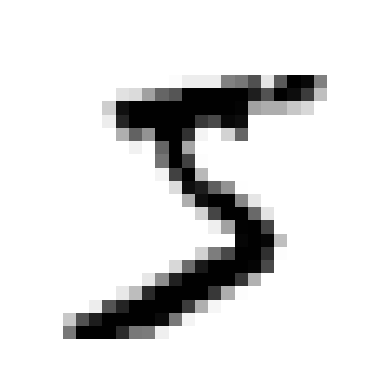

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mlp
some_digit = x[0]
some_image_digit = some_digit.reshape(28,28)
plt.imshow(some_image_digit,cmap=mlp.cm.binary)
plt.axis('off')
plt.show

In [5]:
y[0]

'5'

In [6]:
import numpy as np
y = y.astype(np.uint8)

In [7]:
x_train , x_test , y_train , y_test = x[:60000],x[60000:],y[:60000],y[60000:]

Training a binary classifier

In [8]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [9]:
import numpy as np
print(x_train.shape)
print(y_train.shape)
print(np.unique(y_train, return_counts=True))

(60000, 784)
(60000,)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))


In [10]:
from sklearn.linear_model import SGDClassifier 
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train,y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [11]:
sgd_clf.predict([some_digit])

array([ True])

# Method 1

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(x_train, y_train_5):
    clone_clf = clone(sgd_clf)
    x_train_folds = x_train[train_index]
    y_train_folds = y_train_5[train_index]
    x_test_fold = x_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(x_train_folds, y_train_folds)
    y_pred = clone_clf.predict(x_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9042
0.9477
0.96785


# Method 2 

In [13]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,
               x_train,
               y_train_5,
               cv=3,
               scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [14]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [15]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

# Confussion Matrix

In [16]:
from sklearn.model_selection import cross_val_predict 
y_train_predict = cross_val_predict(sgd_clf,
                 x_train,
                 y_train_5,
                 cv=3)

In [17]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_predict)

array([[53892,   687],
       [ 1891,  3530]])

In [18]:
y_train_perfect_predict = y_train_5
confusion_matrix(y_train_5,y_train_perfect_predict)

array([[54579,     0],
       [    0,  5421]])

# Precision & Recall

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision_score(y_train_5,y_train_predict)

0.8370879772350012

In [20]:
recall_score(y_train_5,y_train_predict)

0.6511713705958311

In [21]:
f1_score(y_train_5,y_train_predict)

0.7325171197343847

In [22]:
y_score = sgd_clf.decision_function([some_digit])
y_score

array([2164.22030239])

In [23]:
threshold = 0
y_somedigit_predict =  (y_score>threshold)
y_somedigit_predict

array([ True])

In [24]:
threshold = 1000
y_somedigit_predict =  (y_score>threshold)
y_somedigit_predict

array([ True])

In [25]:
threshold = 4000
y_somedigit_predict =  (y_score>threshold)
y_somedigit_predict

array([False])

In [26]:
threshold = 8000
y_somedigit_predict =  (y_score>threshold)
y_somedigit_predict

array([False])

In [27]:
y_score = cross_val_predict(sgd_clf,
                           x_train,
                           y_train_5,
                           cv=3,
                           method="decision_function")
y_score

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

In [28]:
from sklearn.metrics import precision_recall_curve
precision,recall,threshold=precision_recall_curve(y_train_5,y_score)

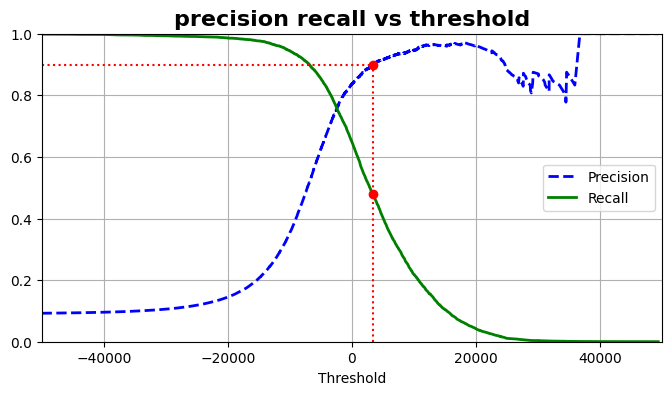

In [29]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right",fontsize=10)
    plt.title('precision recall vs threshold',fontsize='16',fontweight="bold")
    plt.grid(True)
    plt.xlabel('Threshold')
    plt.axis([-50000,50000,0,1])

threshold_90_precision = threshold[np.argmax(precision>=0.90)]
recall_90_precision = recall[np.argmax(precision>=0.90)]

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precision,recall,threshold)
plt.plot([threshold_90_precision, threshold_90_precision],
         [0.0,0.9],
         "r:")
plt.plot([-50000,threshold_90_precision],
         [.9,.9],
         "r:")
plt.plot([threshold_90_precision],
         [.9],
        "ro")
plt.plot([threshold_90_precision],
         [recall_90_precision],
        "ro")
plt.show()

In [30]:
threshold_90_precision

np.float64(3370.0194991439557)

In [31]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_train_5,y_score)

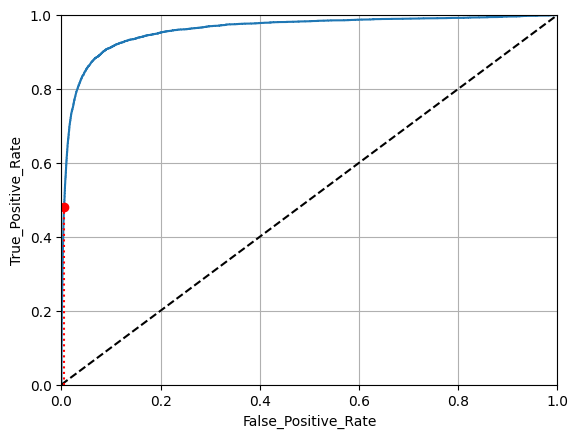

In [32]:
def plot_roc_curve(fpr,tpr):
    plt.plot(fpr,tpr)
    plt.plot([0,1],
            [0,1],
            "k--")
    plt.xlabel("False_Positive_Rate")
    plt.ylabel("True_Positive_Rate")
    plt.grid(True)
    plt.axis([0,1,0,1])

plt.figure(8*4)
plot_roc_curve(fpr,tpr)
fpr_90 = fpr[np.argmax(tpr>=recall_90_precision)]
plt.plot([fpr_90,fpr_90],[0,recall_90_precision],"r:")
plt.plot([fpr_90,0],[recall_90_precision,recall_90_precision])
plt.plot([fpr_90],[recall_90_precision],"ro")
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_score)

0.9604938554008616

In [34]:
from sklearn.ensemble import RandomForestClassifier
forest_clf= RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf,x_train,y_train_5,cv=3,method="predict_proba")
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]], shape=(60000, 2))

In [35]:
y_score_forest = y_probas_forest[:,1]
fpr_forest,tpr_forest,threshold_forest = roc_curve(y_train_5,y_score_forest)

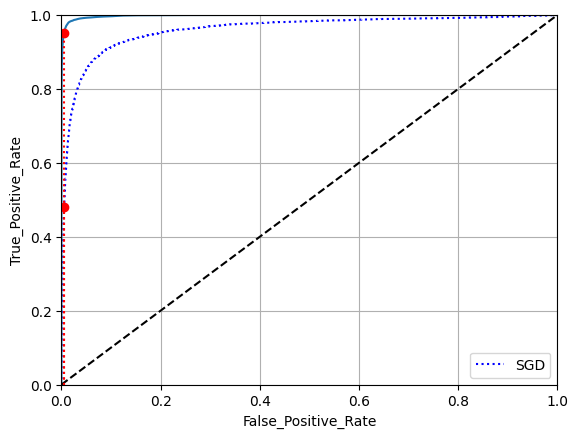

In [36]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest>=fpr_90)]

plt.figure(8*6)
plt.plot(fpr,tpr,"b:",label="SGD")
plot_roc_curve(fpr_forest, tpr_forest)
plt.axis([0,1,0,1])
plt.legend(loc="lower right")

plt.figure(8*6)
plt.plot([fpr_90,fpr_90],[0,recall_90_precision],"r:")
plt.plot([fpr_90,0],[recall_90_precision,recall_90_precision],'r:')
plt.plot([fpr_90],[recall_90_precision],"ro")
plt.plot([fpr_90,fpr_90],[0,recall_for_forest],"r:")
plt.plot([0,fpr_90],[recall_for_forest,recall_for_forest],"r:")
plt.plot([fpr_90],[recall_for_forest],'ro')
plt.show()

In [37]:
roc_auc_score(y_train_5,y_score_forest)

0.9983436731328145

In [38]:
y_train_predict_forest = cross_val_predict(forest_clf,x_train,y_train_5,cv=3)
precision_score(y_train_5,y_train_predict_forest)

0.9905083315756169

In [39]:
recall_score(y_train_5,y_train_predict_forest)

0.8662608374838591

# Multiclass Classifire

In [40]:
from sklearn.svm import SVC
svm_clf = SVC(gamma="auto",random_state = 42)
svm_clf.fit(x_train[:1000],y_train[:1000])
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [41]:
some_digit_score = svm_clf.decision_function([some_digit])
some_digit_score

array([[ 2.81585438,  7.09167958,  3.82972099,  0.79365551,  5.8885703 ,
         9.29718395,  1.79862509,  8.10392157, -0.228207  ,  4.83753243]])

In [42]:
np.argmax([some_digit_score])

np.int64(5)

In [43]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [44]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(gamma = "auto",random_state=42))
ovr_clf.fit(x_train[:1000],y_train[:1000])
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [45]:
len(ovr_clf.estimators_)

10

In [46]:
ovr_clf.estimators_

[SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42)]

In [47]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(x_train,y_train)
ovo_clf.predict([some_digit])

array([5], dtype=uint8)

In [48]:
ovo_clf.decision_function([some_digit])

array([[2.66666766, 3.66666752, 5.33333244, 8.33333288, 0.66666699,
        9.33333311, 0.66666707, 3.6666676 , 4.33333192, 6.33333036]])

In [49]:
cross_val_score(sgd_clf,x_train,y_train,cv=3,scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype(np.float64))
cross_val_score(sgd_clf,x_train_scaled,y_train,cv=3,scoring="accuracy")

C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

# Error Analysis

In [51]:
y_train_pred = cross_val_predict(sgd_clf,x_train_scaled,y_train,cv=3)
cnf_mtx = confusion_matrix(y_train,y_train_pred)
cnf_mtx

C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

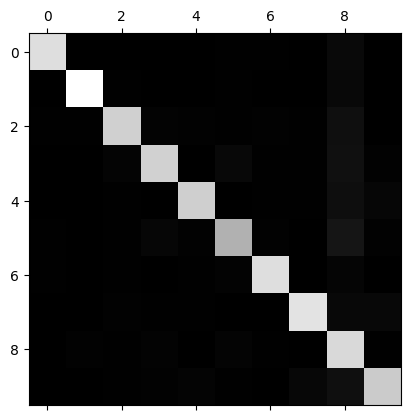

In [52]:
plt.matshow(cnf_mtx,cmap=plt.cm.gray)
plt.show()

In [53]:
def confusion_matrix(matrix):
    fig=plt.figure(8*8)
    ax=fig.add_subplot(111)
    cax = ax.matshow(matrix)
    fig.colorbar(cax)

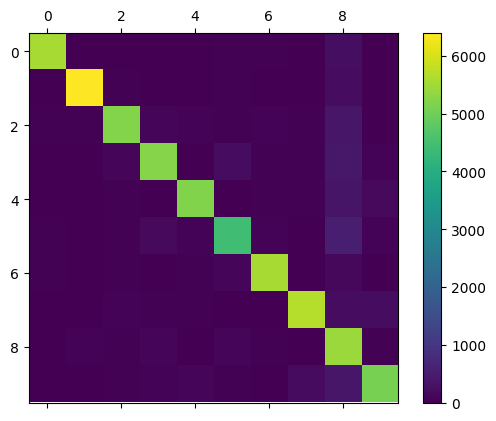

In [54]:
confusion_matrix(cnf_mtx)

In [55]:
row_sum = cnf_mtx.sum(axis =1,keepdims=True)
normal_cnf_mtx = cnf_mtx/row_sum
normal_cnf_mtx

array([[9.40908323e-01, 0.00000000e+00, 3.88316731e-03, 8.44166807e-04,
        1.35066689e-03, 7.42866790e-03, 6.07800101e-03, 1.01300017e-03,
        3.83251731e-02, 1.68833361e-04],
       [0.00000000e+00, 9.48976565e-01, 5.48798576e-03, 3.55977455e-03,
        5.93295758e-04, 6.37792940e-03, 5.93295758e-04, 1.03826758e-03,
        3.17413230e-02, 1.63156333e-03],
       [4.86740517e-03, 4.19603894e-03, 8.76132931e-01, 1.52735817e-02,
        1.22524337e-02, 4.19603894e-03, 1.14132259e-02, 6.04229607e-03,
        6.37797919e-02, 1.84625713e-03],
       [3.58832164e-03, 2.77279400e-03, 1.90833469e-02, 8.52063285e-01,
        3.26211059e-04, 3.32735280e-02, 4.40384929e-03, 6.52422117e-03,
        6.60577394e-02, 1.19067036e-02],
       [2.05409106e-03, 2.39643958e-03, 6.84697022e-03, 1.54056830e-03,
        8.86853817e-01, 2.05409106e-03, 5.81992468e-03, 4.27935638e-03,
        6.00821636e-02, 2.80725779e-02],
       [4.79616307e-03, 2.76701716e-03, 5.34956650e-03, 3.04371887e-02,
   

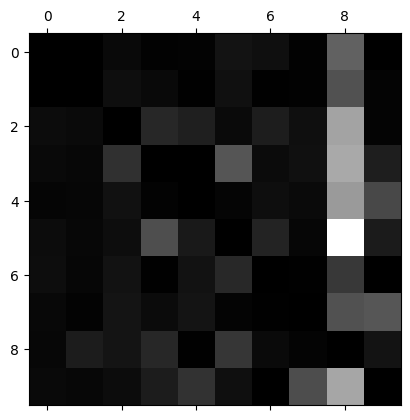

In [56]:
np.fill_diagonal(normal_cnf_mtx,0)
plt.matshow(normal_cnf_mtx,cmap=plt.cm.gray)
plt.show()

In [57]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mlp.cm.binary, **options)
    plt.axis("off")

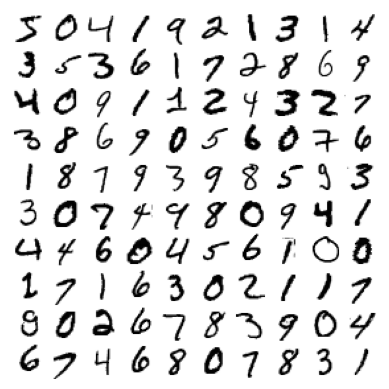

In [71]:
plt.figure(9*9)
example_images=x[:100]
plot_digits(example_images,images_per_row=10)
plt.show()

In [58]:
y_train_pred = cross_val_predict(sgd_clf,
                 x_train,
                 y_train,
                 cv=3)

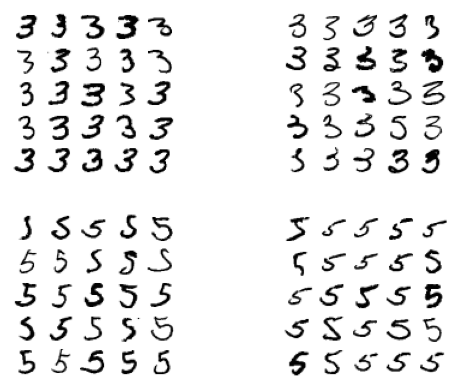

In [59]:
cl_a= 3
cl_b = 5

x_aa = x_train[(y_train==cl_a)&(y_train_pred==cl_a)]
x_ab = x_train[(y_train==cl_a)&(y_train_pred==cl_b)]
x_ba = x_train[(y_train==cl_b)&(y_train_pred==cl_a)]
x_bb = x_train[(y_train==cl_b)&(y_train_pred==cl_b)]

plt.figure(8*8)
plt.subplot(221);plot_digits(x_aa[:25],images_per_row=5)
plt.subplot(222);plot_digits(x_ab[:25],images_per_row=5)
plt.subplot(223);plot_digits(x_ba[:25],images_per_row=5)
plt.subplot(224);plot_digits(x_bb[:25],images_per_row=5)
plt.show()

In [60]:
x_ab = x_train[(y_train==3)&(y_train_predict==3)]
x_ab

array([], shape=(0, 784), dtype=int64)

In [61]:
print(y_train.shape)
print(y_train_predict.shape)

print(np.unique(y_train, return_counts=True))
print(np.unique(y_train_predict, return_counts=True))

(60000,)
(60000,)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))
(array([False,  True]), array([55783,  4217]))


In [62]:
print("Actual 3:", np.sum(y_train == 3))
print("Actual 5:", np.sum(y_train == 5))

print("Predicted 3:", np.sum(y_train_predict == 3))
print("Predicted 5:", np.sum(y_train_predict == 5))


Actual 3: 6131
Actual 5: 5421
Predicted 3: 0
Predicted 5: 0


In [63]:
len(x_aa)
len(x_aa)
len(x_aa)


4953

In [64]:
print(np.unique(y_train))
print(np.unique(y_train_predict))

[0 1 2 3 4 5 6 7 8 9]
[False  True]


# Multilabel Classifier

In [65]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large,y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train,y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [66]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [67]:
y_train_knn_pred = cross_val_predict(knn_clf, x_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [68]:
len(x_test)

10000

In [73]:
noise = np.random.randint(0, 100, (len(x_train), 784))
x_train_mod = x_train + noise
noise = np.random.randint(0, 100, (len(x_test), 784))
x_test_mod = x_test + noise
y_train_mod = x_train
y_test_mod = x_test

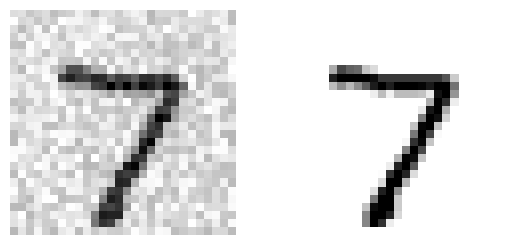

In [76]:
some_index = 0

plt.subplot(121)
plot_digits(x_test_mod[some_index].reshape(1, -1))

plt.subplot(122)
plot_digits(x_test[some_index].reshape(1, -1))

plt.show()

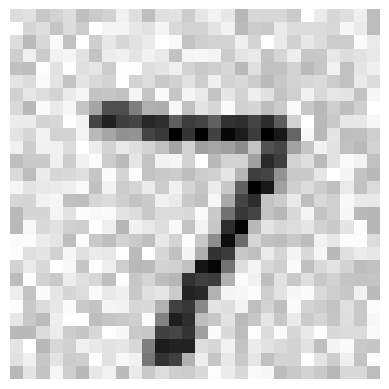

In [77]:
plot_digits(x_test_mod[some_index].reshape(1, -1))

In [78]:
x_test_mod[some_index].shape

(784,)

In [79]:
x_test_mod[some_index].shape

(784,)

In [80]:
y_test_mod[some_index].shape

(784,)

In [81]:
y_train_mod[some_index].shape

(784,)

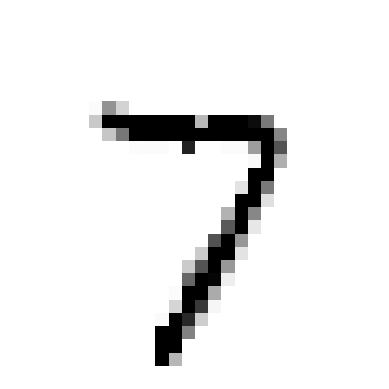

In [82]:
knn_clf.fit(x_train_mod, y_train_mod) 
clean_digit = knn_clf.predict([x_test_mod[some_index]]) 
plot_digits(clean_digit)

# Data Argument

In [83]:
from scipy.ndimage.interpolation import shift

C:\Users\anshu\AppData\Local\Temp\ipykernel_9832\987197595.py:1: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift


In [84]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

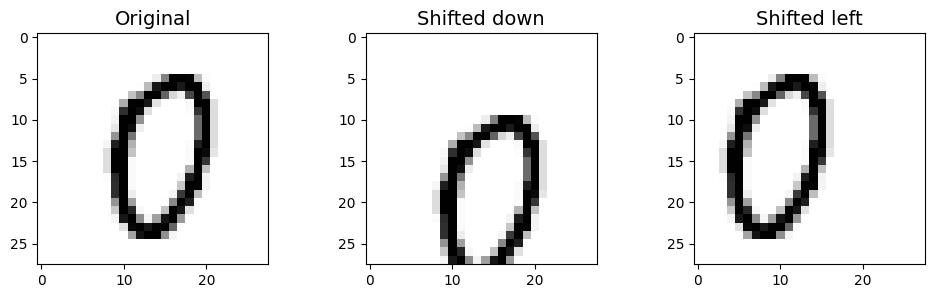

In [85]:
image = x_train[1000]
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

plt.figure(figsize=(12,3))
plt.subplot(131)
plt.title("Original", fontsize=14)
plt.imshow(image.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(132)
plt.title("Shifted down", fontsize=14)
plt.imshow(shifted_image_down.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(133)
plt.title("Shifted left", fontsize=14)
plt.imshow(shifted_image_left.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.show()